## Middleware

In [9]:
from langchain.chat_models import init_chat_model

groq_model = init_chat_model(model = "groq:qwen/qwen3-32b")

In [1]:
from langchain_groq import ChatGroq

groq_model = ChatGroq(
    model="qwen/qwen3-32b",
    temperature=0,
    max_tokens=None,
    reasoning_format="parsed",
    timeout=None,
    max_retries=2,
    # other params...
)

In [10]:
from langchain.agents import create_agent
from langchain.agents.middleware import SummarizationMiddleware
from langgraph.checkpoint.memory import InMemorySaver
from langchain_core.messages import HumanMessage ,SystemMessage

agent = create_agent(
    model=groq_model,
    checkpointer=InMemorySaver(),
    middleware=[
        SummarizationMiddleware(
            model=groq_model,
            trigger=("messages",10),
            keep=("messages",4)
        )
    ]
)

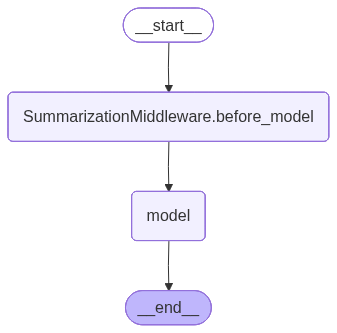

In [11]:
agent

In [12]:
config = {"configurable":{"thread_id":"test-1"}}

In [13]:
questions = [
    "what is 2 + 2 ?",
    "what is 10*5 ?",
    "what is 3*8 ? ",
    "what is 50/10 ?",
]


for q in questions:
    response = agent.invoke({"messages":[HumanMessage(content=q)]},config)
    print(f"messages:{response}")
    print(f"message length: {len(response["messages"])}")
    # print(q)

messages:{'messages': [HumanMessage(content='what is 2 + 2 ?', additional_kwargs={}, response_metadata={}, id='cc565439-9fbc-4cbc-9d1f-ed4cd50965e3'), AIMessage(content="<think>\nOkay, the user is asking what is 2 + 2. Let me think about how to approach this. At first glance, it seems like a simple arithmetic problem, but maybe they want a detailed explanation.\n\nHmm, 2 + 2 is basic addition. The answer is 4, right? But wait, sometimes people might get confused with similar-looking numbers. Let me verify. If I count two objects and then add two more, that's four total. Yeah, that makes sense. \n\nWait, could there be any trick here? Like, is it a riddle where the answer isn't four? For example, in some contexts like a clock, 2 + 2 might refer to adding hours, but the question doesn't specify that. So probably, it's straightforward. \n\nLet me also consider different number systems. In binary, 2 is represented as 10. Adding 10 + 10 in binary would be 100, which is 4 in decimal. So even

# Token size

In [45]:
from langchain.agents import create_agent
from langchain_core.messages import HumanMessage
from langgraph.checkpoint.memory import InMemorySaver
from langchain.agents.middleware import SummarizationMiddleware
from langchain_core.tools import tool


@tool
def search_hotels(city:str) -> str:
   """search hotels and gives a long response """
   return f"""Hotels in {city}:
   1. Grand Hotel - 5 star, $350/night, spa, pool, gym 
   2. City Inn - 4 star, $180/night, business center 
   3. Budget Stay - 3 star, $75/night, free Wi-Fi"""



agent2 = create_agent(
    model="groq:llama-3.1-8b-instant",
    tools=[search_hotels],
    checkpointer=InMemorySaver(),
    middleware=[
        SummarizationMiddleware(
            model="groq:llama-3.1-8b-instant",
            trigger=("tokens", 550),
            keep=("tokens", 200)
        )
    ]
)




In [35]:
config = {"configurable":{"thread_id":"test-1"}}

In [32]:
!pip show transformers

Name: transformers
Version: 4.57.1
Summary: State-of-the-art Machine Learning for JAX, PyTorch and TensorFlow
Home-page: https://github.com/huggingface/transformers
Author: The Hugging Face team (past and future) with the help of all our contributors (https://github.com/huggingface/transformers/graphs/contributors)
Author-email: transformers@huggingface.co
License: Apache 2.0 License
Location: /opt/homebrew/Caskroom/miniconda/base/lib/python3.13/site-packages
Requires: filelock, huggingface-hub, numpy, packaging, pyyaml, regex, requests, safetensors, tokenizers, tqdm
Required-by: livekit-plugins-turn-detector


In [42]:
def count_messages_token(messages):
    tot_chars = sum(len(str(m.content)) for m in messages)
    length = tot_chars // 4

    return length

# def count_messages_tokens(messages, model):
#     """Use LangChain's built-in token counter if available."""
#     try:
#         return model.get_num_tokens_from_messages(messages)
#     except (NotImplementedError, AttributeError):
#         # Fallback to tiktoken
#         import tiktoken
#         encoding = tiktoken.get_encoding("cl100k_base")
#         return sum(len(encoding.encode(str(m.content))) for m in messages)

In [46]:
cities = [
    "Tokyo","London","Paris","Dubai"
]


for c in cities:
    print(f"----querying for city : {c} ----")
    response = agent.invoke({"messages":[HumanMessage(content=f"find me a hotel in {c}")]},config=config)
    tokens = count_messages_token(response["messages"])
    print(f"city {c},no of tokens : {tokens},length of messages:{len(response["messages"])}")
    print(f"message : {response["messages"]}")
    print("\n\n")

----querying for city : Tokyo ----
city Tokyo,no of tokens : 2309,length of messages:6
message : [HumanMessage(content="Here is a summary of the conversation to date:\n\n<think>\nOkay, let's tackle this. The user wants me to extract the most relevant context from the conversation history between the human and the AI. The conversation includes two requests for hotels in Paris and Dubai, each followed by detailed responses from the AI. My job is to summarize the key points from these interactions to replace the conversation history.\n\nFirst, I need to identify the main elements from each hotel search. For Paris, the AI provided a structured guide with areas, hotel options across different price ranges, booking tips, budget breakdowns, and pro tips. It also included visa information. For Dubai, the structure is similar, with areas, hotels, booking advice, budget info, and visa details.\n\nI should focus on the most important information that's repeated or essential for future interaction

In [12]:
print(response["messages"][0])

content='Here is a summary of the conversation to date:\n\n<think>\nOkay, the user is asking "what is 50 divided by 10?" Let me think about how to approach this. They\'ve been working on basic arithmetic problems like addition, multiplication, and now division. The previous interactions were straightforward, so this should be another simple division problem.\n\nFirst, I know that dividing 50 by 10 is asking how many times 10 fits into 50. Since 10 times 5 is 50, the answer should be 5. Let me verify that. If I multiply 10 by 5, I get 50, which confirms that 50 divided by 10 is indeed 5. \n\nAlternatively, I can use the concept of place value. Dividing by 10 moves the decimal point one place to the left. So 50 becomes 5.0, which is 5. That makes sense. \n\nAnother way to think about it is grouping. If you have 50 objects and divide them into 10 equal groups, each group would have 5 objects. \n\nI should also check if there\'s any possibility of a different result, but in standard arithm

In [16]:
!pip show langchain

Name: langchain
Version: 1.2.0
Summary: Building applications with LLMs through composability
Home-page: https://docs.langchain.com/
Author: 
Author-email: 
License: MIT
Location: /opt/homebrew/Caskroom/miniconda/base/lib/python3.13/site-packages
Requires: langchain-core, langgraph, pydantic
Required-by: 


## Fraction

In [47]:
from langchain.agents import create_agent
from langchain_core.messages import HumanMessage
from langgraph.checkpoint.memory import InMemorySaver
from langchain.agents.middleware import SummarizationMiddleware
from langchain_core.tools import tool


@tool
def search_hotels(city:str) -> str:
   """search hotels and gives a long response """
   return f"""Hotels in {city}:
   1. Grand Hotel - 5 star, $350/night
   2. City Inn - 4 star, $180/night
   3. Budget Stay - 3 star, $75/night"""




agent3 = create_agent(
    model="groq:llama-3.1-8b-instant",
    tools=[search_hotels],
    checkpointer=InMemorySaver(),
    middleware=[
        SummarizationMiddleware(
            model="groq:llama-3.1-8b-instant",
            trigger=("fraction", 0.005),
            keep=("fraction", 0.002)
        )
    ]
)

config = {"configurable":{"thread_id":"test-1"}}


def count_messages_token(messages):
    tot_chars = sum(len(str(m.content)) for m in messages)
    length = tot_chars // 4

    return length


cities = [
    "Tokyo","London","Paris","Dubai", "New York","Los Angeles","Chicago"
]


for c in cities:
    print(f"----querying for city : {c} ----")
    response = agent.invoke({"messages":[HumanMessage(content=f"find me a hotel in {c}")]},config=config)
    tokens = count_messages_token(response["messages"])
    fraction = tokens / 128000
    print(f"city {c} ~  tokens {tokens} ({fraction:.4%}) ,length of messages:{len(response["messages"])}")
    print(f"message : {response["messages"]}")
    print("\n\n")

----querying for city : Tokyo ----
city Tokyo ~  tokens 6975 (5.4492%) ,length of messages:8
message : [HumanMessage(content='Here is a summary of the conversation to date:\n\n<think>\nOkay, the user wants a hotel in London. Let me recall the previous interactions. They asked for Paris, Dubai, and Tokyo, each time getting a structured guide with areas, hotel options by budget, tips, and visa info. The user is probably expecting the same format here.\n\nFirst, I need to outline popular areas in London. Central areas like London Bridge, Covent Garden, Soho, Oxford Street, and Canary Wharf come to mind. Each area has different vibes and attractions. For example, London Bridge is historic and central, while Canary Wharf is more business-oriented.\n\nNext, list hotels in each area across budget tiers. Budget options might include Premier Inn or Ibis. Mid-range could be The Montcalm or Novotel. Luxury would be The Ritz London or The Savoy. I should check approximate prices in pounds and mayb

## Humanintheloop midddleware

- this is to interrupt very important decision so at the end we are the ones who approve or reject a certain decision


In [50]:
from langchain.agents import create_agent
from langchain_core.messages import HumanMessage
from langgraph.checkpoint.memory import InMemorySaver
from langchain.agents.middleware import HumanInTheLoopMiddleware
from langchain_core.tools import tool


def read_email_tool(email_id:str) -> str:
    """mock function to read email content based on email id"""
    return f"Email content for {email_id}"

def send_email_tool(recipient:str,subject:str,body:str) ->str:
    """mock function to send email"""
    return f"Email sent to {recipient} with subject '{subject}'"

In [51]:
email_agent = create_agent(
    model="groq:llama-3.1-8b-instant",
    tools=[send_email_tool,read_email_tool],
    checkpointer=InMemorySaver(),
    middleware=[
        HumanInTheLoopMiddleware(
            interrupt_on={
                "send_email_tool":{
                    "allowed_decisions":["approve","edit","reject"]
                },
                "read_email_tool":False
            }
        )
    ]
)

In [52]:
config = {"configurable":{"thread_id":"test-approve"}}


response = email_agent.invoke({
    "messages":[HumanMessage(content="Send email to john@test.com with subject 'Hello' and body 'Just wanted to say hi!'")]
},
config=config
)

In [53]:
from langgraph.types import Command

if "__interrupt__" in response:
    print("paused! Awaiting human approval...")

    result = email_agent.invoke(
        Command(
            resume={
                "decisions":[
                    {"type":"approve"}
                ]
            }
        ),
        config=config
    )

    print(f"Result : {result['messages'][-1].content}")





paused! Awaiting human approval...
Result : Email sent to john@test.com with subject 'Hello'


## Reject Scenario

In [54]:
email_agent_2 = create_agent(
    model="groq:llama-3.1-8b-instant",
    tools=[send_email_tool,read_email_tool],
    checkpointer=InMemorySaver(),
    middleware=[
        HumanInTheLoopMiddleware(
            interrupt_on={
                "send_email_tool":{
                    "allowed_decisions":["approve","edit","reject"]
                },
                "read_email_tool":False
            }
        )
    ]
)

In [55]:
config = {"configurable":{"thread_id":"test-reject"}}


response = email_agent.invoke({
    "messages":[HumanMessage(content="Send email to john@test.com with subject 'Hello' and body 'Just wanted to say hi!'")]
},
config=config
)

In [ ]:
if "__interrupt__" in response:
    print("paused! Awaiting human approval...")

    result = email_agent_2.invoke(
        Command(
            resume={
                "decisions":[
                    {"type":"reject"}
                ]
            }
        ),
        config=config
    )
    if result['messages'][-1].content :
        print(f"Result : {result['messages'][-1].content}")
    else:
        print("Email sending was rejected by human.")

paused! Awaiting human approval...
Email sending was rejected by human.


## Editing Scenario

In [59]:
email_agent_3 = create_agent(
    model="groq:llama-3.1-8b-instant",
    tools=[send_email_tool,read_email_tool],
    checkpointer=InMemorySaver(),
    middleware=[
        HumanInTheLoopMiddleware(
            interrupt_on={
                "send_email_tool":{
                    "allowed_decisions":["approve","edit","reject"]
                },
                "read_email_tool":False
            }
        )
    ]
)

In [65]:
config = {"configurable":{"thread_id":"test-edit"}}


response = email_agent_3.invoke({
    "messages":[HumanMessage(content="Send email to john@test.com with subject 'Hello' and body 'Just wanted to say hi!'")]
},
config=config
)

In [66]:
if "__interrupt__" in response:
    print("paused! Awaiting human approval...")

    result = email_agent_3.invoke(
        Command(
            resume={
                "decisions":[
                    {"type":"edit",
                     "edited_action":{
                         "name":"send_email_tool",
                         "args":{
                             "recipient":"correct@gmail.com",
                             "subject":"corrected subject",
                             "body":"this was edited by a human before sending"
                         }
                     }}
                ]
            }
        ),
        config=config
    )
    if result['messages'][-1].content :
        print(f"Result : {result['messages'][-1].content}")
    else:
        print("Email sending was rejected by human.")

paused! Awaiting human approval...
Email sending was rejected by human.
